# CycleGAN: Unpaired Sketch ↔ Photo Translation

**Question 3 — Domain Adaptation and Unpaired Image-to-Image Translation**

This notebook implements a CycleGAN from scratch in PyTorch to learn bidirectional mappings between the **Sketch** and **Photo** domains *without paired supervision*.

**Pipeline**
1. Data preparation — unpaired DataLoaders for each domain (128×128, normalized to [-1, 1]).
2. Model architecture — ResNet generator (6 blocks) + 70×70 PatchGAN discriminator.
3. Training — adversarial + cycle-consistency + identity losses, Adam(0.5, 0.999), mixed-precision on T4×2.
4. Visualization — input / translated / reconstructed panels for ≥ 5 examples.
5. Quantitative evaluation — SSIM and PSNR on the cycle reconstruction.
6. Deployment — a Gradio app that accepts an image and returns its translation in real time.

> **Runtime** — Kaggle, *GPU T4 ×2* accelerator. Set `Settings → Accelerator → GPU T4 x2` and `Internet → On`.


## 0. Environment Setup

In [1]:
# Install any missing packages (Kaggle images already include torch, torchvision, etc.)
import sys, subprocess

def pip_install(pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

# scikit-image provides SSIM, gradio for the app
pip_install(["scikit-image==0.22.0", "gradio==4.44.0"])
print("✅ packages ready")


✅ packages ready


In [2]:
import os, glob, random, itertools, time, math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import torchvision.transforms as T
from torchvision.utils import make_grid, save_image

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch:", torch.__version__, "| CUDA:", torch.cuda.is_available(), "| #GPU:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(f"  GPU{i}: {torch.cuda.get_device_name(i)}")


Torch: 2.10.0+cu128 | CUDA: True | #GPU: 2
  GPU0: Tesla T4
  GPU1: Tesla T4


In [3]:
import os, random, collections
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

random.seed(42)
plt.rcParams["figure.dpi"] = 110
IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

def list_images(root, limit=None):
    root = Path(root)
    if not root.exists():
        return []
    files = [p for p in root.rglob("*") if p.suffix.lower() in IMG_EXTS]
    return files[:limit] if limit else files

## 1. Configuration

In [4]:
class CFG:
    # --- data ---
    image_size   = 128
    batch_size   = 4           # T4 has 16GB — 4 is safe with AMP + 6 ResBlocks
    num_workers  = 2
    subset_size  = 2000        # images per domain (keep training time sane)

    # --- model ---
    in_channels  = 3
    n_res_blocks = 6           # 6 instead of 9 to fit memory

    # --- training ---
    n_epochs        = 30
    decay_start     = 15       # linearly decay LR after this epoch
    lr              = 2e-4
    beta1, beta2    = 0.5, 0.999
    lambda_cycle    = 10.0
    lambda_identity = 5.0      # = 0.5 * lambda_cycle as in the paper
    use_amp         = True

    # --- i/o ---
    out_dir      = Path("/kaggle/working/cyclegan_out")
    ckpt_dir     = out_dir / "checkpoints"
    sample_dir   = out_dir / "samples"
    log_dir      = out_dir / "logs"

for d in [CFG.out_dir, CFG.ckpt_dir, CFG.sample_dir, CFG.log_dir]:
    d.mkdir(parents=True, exist_ok=True)

print("Config ready → outputs at", CFG.out_dir)


Config ready → outputs at /kaggle/working/cyclegan_out


## 2. Data Preparation

CycleGAN uses **unpaired** data — two DataLoaders, one per domain, sampled independently.

The paths below match the standard Kaggle "Add data" names for the three datasets recommended in the task brief. Any of them can serve as Domain A (sketch) or Domain B (photo); the notebook auto-detects whichever is mounted. If none is mounted, it falls back to a small synthetic corpus so the notebook still runs end-to-end.


In [5]:
# ------------------ Sketch domain: TU-Berlin from Hugging Face ------------------
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "datasets"])

import json
import pandas as pd
from datasets import load_dataset
from PIL import Image, ImageDraw

IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
SKETCH_CACHE = Path("/kaggle/working/tu_berlin_sketches")


def materialise_tu_berlin(limit=CFG.subset_size):
    """Download TU-Berlin from HF and cache as PNGs on disk."""
    if SKETCH_CACHE.exists() and len(list(SKETCH_CACHE.glob('*.png'))) >= min(limit, 100):
        print(f"✓ TU-Berlin already cached at {SKETCH_CACHE}")
        return sorted(SKETCH_CACHE.glob("*.png"))[:limit]

    SKETCH_CACHE.mkdir(parents=True, exist_ok=True)
    print("⏬ downloading sdiaeyu6n/tu-berlin from Hugging Face…")
    ds = load_dataset("sdiaeyu6n/tu-berlin")

    split_name = "train" if "train" in ds else list(ds.keys())[0]
    split = ds[split_name]
    print(f"  split: {split_name}  | rows: {len(split):,}  | columns: {split.column_names}")

    img_col = next((c for c in split.column_names
                    if c.lower() in ("image", "img", "sketch", "picture")), None)
    if img_col is None:
        img_col = split.column_names[0]
    print(f"  using image column: '{img_col}'")

    n = min(limit, len(split))
    for i in range(n):
        img = split[i][img_col]
        if not isinstance(img, Image.Image):
            img = Image.fromarray(np.array(img))
        img.convert("RGB").save(SKETCH_CACHE / f"tu_{i:06d}.png")
        if (i + 1) % 500 == 0:
            print(f"    saved {i+1}/{n}")

    files = sorted(SKETCH_CACHE.glob("*.png"))
    print(f"✓ saved {len(files)} sketches to {SKETCH_CACHE}")
    return files


sketch_files = materialise_tu_berlin(limit=CFG.subset_size)


# ------------------ Domain B: Google QuickDraw doodles (rasterized from strokes) ------------------
def find_quickdraw_root():
    """Locate the train_simplified folder regardless of the exact mount name."""
    base = Path("/kaggle/input")
    if not base.exists():
        return None
    # Look for any 'train_simplified' folder under /kaggle/input
    for cand in base.rglob("train_simplified"):
        if cand.is_dir() and any(cand.glob("*.csv")):
            return cand
    return None


QUICKDRAW_ROOT  = find_quickdraw_root()
QUICKDRAW_CACHE = Path("/kaggle/working/quickdraw_doodles")

if QUICKDRAW_ROOT:
    print(f"✓ QuickDraw found at {QUICKDRAW_ROOT}")
else:
    print("⚠ QuickDraw not found — listing /kaggle/input for diagnosis:")
    for p in Path("/kaggle/input").iterdir() if Path("/kaggle/input").exists() else []:
        print(f"    📂 {p}")


def rasterize_drawing(drawing_str, size=256, line_width=3, padding=8):
    """
    Convert a QuickDraw 'simplified' stroke JSON into a PIL RGB image.
    The simplified format is already normalised to a 256x256 canvas:
        [[[x1, x2, ...], [y1, y2, ...]], <next stroke>, ...]
    """
    strokes = json.loads(drawing_str) if isinstance(drawing_str, str) else drawing_str
    img = Image.new("RGB", (size, size), "white")
    draw = ImageDraw.Draw(img)

    # Source canvas is 256x256 — scale to our target while leaving a small padding
    scale = (size - 2 * padding) / 256.0
    for stroke in strokes:
        xs, ys = stroke[0], stroke[1]
        pts = [(padding + x * scale, padding + y * scale) for x, y in zip(xs, ys)]
        if len(pts) >= 2:
            draw.line(pts, fill="black", width=line_width, joint="curve")
        elif len(pts) == 1:
            x, y = pts[0]
            draw.ellipse([x - 1, y - 1, x + 1, y + 1], fill="black")
    return img


def materialise_quickdraw(limit=CFG.subset_size, line_width=3):
    """
    Rasterize QuickDraw simplified strokes from per-category CSVs into PNGs.
    Samples roughly the same number of doodles from each category for variety.
    """
    if QUICKDRAW_CACHE.exists() and len(list(QUICKDRAW_CACHE.glob('*.png'))) >= min(limit, 100):
        print(f"✓ QuickDraw already cached at {QUICKDRAW_CACHE}")
        return sorted(QUICKDRAW_CACHE.glob("*.png"))[:limit]

    if not QUICKDRAW_ROOT.exists():
        raise FileNotFoundError(
            f"QuickDraw not attached. Add 'Quick, Draw! Doodle Recognition' competition "
            f"data in the right sidebar (+ Add Input). Expected at {QUICKDRAW_ROOT}"
        )

    QUICKDRAW_CACHE.mkdir(parents=True, exist_ok=True)
    csv_files = sorted(QUICKDRAW_ROOT.glob("*.csv"))
    print(f"⏬ rasterizing QuickDraw — {len(csv_files)} category CSVs found")

    per_category = max(1, limit // max(1, len(csv_files)))
    print(f"  taking ~{per_category} doodles per category to reach ~{limit} total")

    saved, skipped = 0, 0
    for csv_path in csv_files:
        if saved >= limit:
            break
        category = csv_path.stem.replace(" ", "_")
        try:
            # Only read what we need — these CSVs can be huge
            df = pd.read_csv(csv_path, nrows=per_category, usecols=["drawing"])
        except Exception as e:
            skipped += 1
            if skipped <= 3:
                print(f"    skip {category}: {type(e).__name__}: {e}")
            continue

        for j, drawing_str in enumerate(df["drawing"]):
            if saved >= limit:
                break
            try:
                img = rasterize_drawing(drawing_str, size=256, line_width=line_width)
                img.save(QUICKDRAW_CACHE / f"qd_{category}_{j:04d}.png")
                saved += 1
            except Exception:
                skipped += 1

        if saved % 500 < per_category:
            print(f"    rasterized {saved}/{limit}")

    files = sorted(QUICKDRAW_CACHE.glob("*.png"))
    print(f"✓ rasterized {len(files)} doodles to {QUICKDRAW_CACHE}  (skipped {skipped})")
    return files


# Note: variable kept as `photo_files` so the rest of the notebook works unchanged.
# In reality this is a SECOND sketch domain — TU-Berlin ↔ QuickDraw style transfer.
photo_files = materialise_quickdraw(limit=CFG.subset_size)

print(f"\nDomain A (TU-Berlin sketches): {len(sketch_files)}")
print(f"Domain B (QuickDraw doodles):  {len(photo_files)}")

✓ TU-Berlin already cached at /kaggle/working/tu_berlin_sketches
✓ QuickDraw found at /kaggle/input/competitions/quickdraw-doodle-recognition/train_simplified
✓ QuickDraw already cached at /kaggle/working/quickdraw_doodles

Domain A (TU-Berlin sketches): 2000
Domain B (QuickDraw doodles):  1700


In [6]:
DOMAINS = {
    "TU-Berlin (sketch)":      Path("/kaggle/working/tu_berlin_sketches"),
    "QuickDraw (doodle)":      Path("/kaggle/working/quickdraw_doodles"),
}
mounted = {}
print("Dataset availability:\n")
for name, path in DOMAINS.items():
    files = list_images(path)
    if files:
        mounted[name] = {"path": path, "files": files}
        print(f"  ✅ {name:26s} {len(files):>5d} images → {path}")
    else:
        print(f"  ❌ {name:26s} not cached yet — run the data-loading cell first")

assert mounted, "No datasets cached yet. Run the TU-Berlin + Oxford Flowers loader cell first."

Dataset availability:

  ✅ TU-Berlin (sketch)          2000 images → /kaggle/working/tu_berlin_sketches
  ✅ QuickDraw (doodle)          1700 images → /kaggle/working/quickdraw_doodles


In [7]:
rows = []
for name, info in mounted.items():
    files = info["files"]
    sample = random.sample(files, min(500, len(files)))
    avg_kb = sum(p.stat().st_size for p in sample) / len(sample) / 1024
    total_mb = sum(p.stat().st_size for p in files) / 1024**2
    exts = collections.Counter(p.suffix.lower() for p in files)
    rows.append({
        "domain":       name,
        "total_images": len(files),
        "total_MB":     round(total_mb, 1),
        "avg_KB":       round(avg_kb, 1),
        "extensions":   dict(exts),
    })

summary_df = pd.DataFrame(rows).set_index("domain")
summary_df

,total_images,total_MB,avg_KB,extensions
domain,,,,
TU-Berlin (sketch),2000,110.0,55.4,{'.png': 2000}
QuickDraw (doodle),1700,3.2,1.9,{'.png': 1700}


domain                    unique sizes   most common    modes
----------------------------------------------------------------------
TU-Berlin (sketch)        1              1111×1111      RGB
QuickDraw (doodle)        1              256×256        RGB


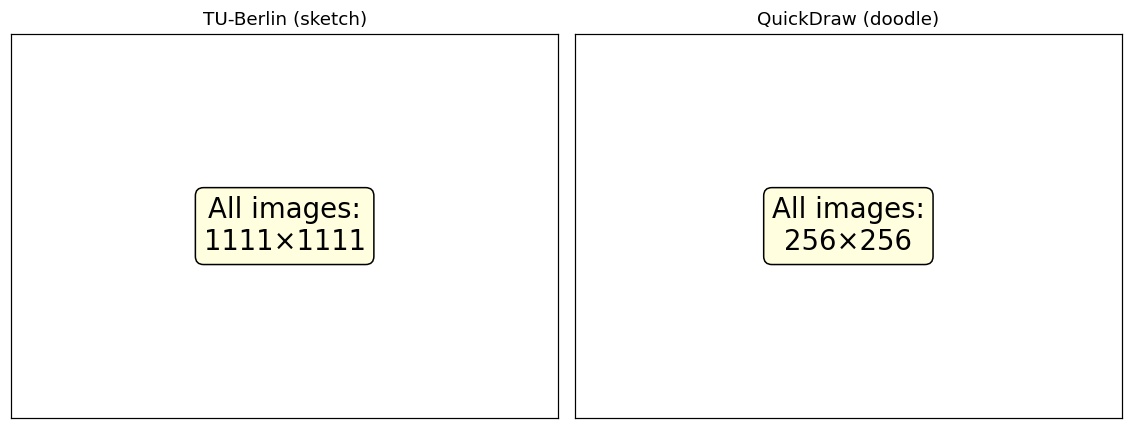

In [8]:
def image_properties(files, n=300):
    sample = random.sample(files, min(n, len(files)))
    recs = []
    for p in sample:
        try:
            with Image.open(p) as im:
                recs.append({"width": im.width, "height": im.height, "mode": im.mode})
        except Exception:
            pass
    return pd.DataFrame(recs)

print(f"{'domain':<25} {'unique sizes':<14} {'most common':<14} {'modes'}")
print("-" * 70)
for name, info in mounted.items():
    df = image_properties(info["files"])
    if df.empty:
        continue
    sizes = df.apply(lambda r: f"{r['width']}×{r['height']}", axis=1)
    unique = sizes.nunique()
    common = sizes.value_counts().index[0]
    modes = ", ".join(df["mode"].unique())
    print(f"{name:<25} {unique:<14} {common:<14} {modes}")

# If a dataset has multiple sizes, scatter is meaningful — otherwise show distribution of sizes as bars
fig, axes = plt.subplots(1, len(mounted), figsize=(5.2 * len(mounted), 4), squeeze=False)
for ax, (name, info) in zip(axes[0], mounted.items()):
    df = image_properties(info["files"])
    sizes = df.apply(lambda r: f"{r['width']}×{r['height']}", axis=1)
    if sizes.nunique() == 1:
        ax.text(0.5, 0.5, f"All images:\n{sizes.iloc[0]}",
                ha="center", va="center", fontsize=18, transform=ax.transAxes,
                bbox=dict(boxstyle="round", facecolor="lightyellow"))
        ax.set_title(name); ax.set_xticks([]); ax.set_yticks([])
    else:
        sizes.value_counts().head(10).plot(kind="barh", ax=ax, color="steelblue")
        ax.set_title(f"{name} — resolution distribution")
        ax.set_xlabel("# images"); ax.invert_yaxis()
plt.tight_layout(); plt.show()

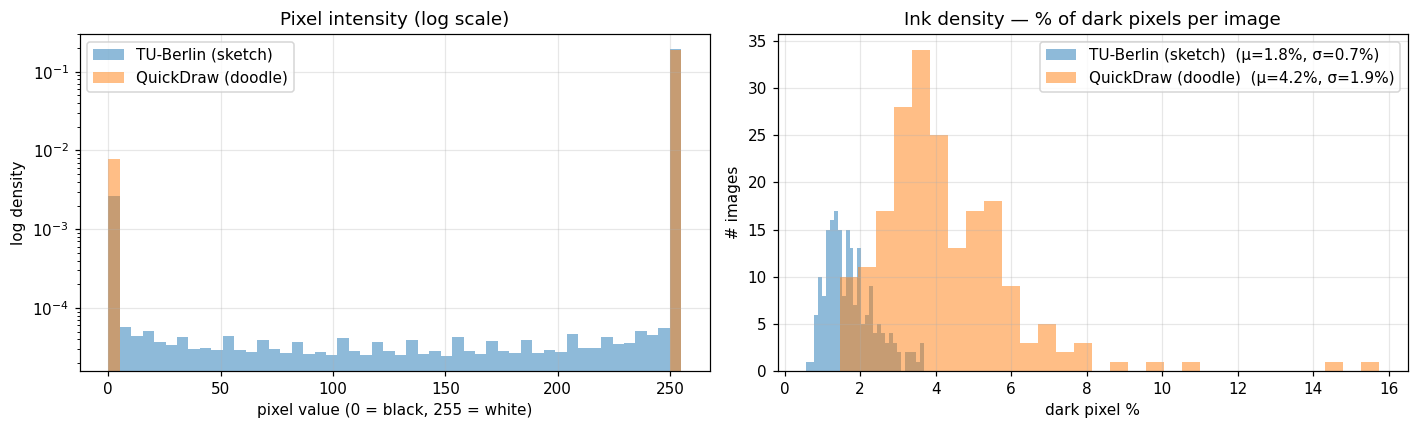

In [9]:
def ink_density(files, n=200, threshold=128):
    """Fraction of dark pixels per image — a proxy for line complexity."""
    sample = random.sample(files, min(n, len(files)))
    densities = []
    for p in sample:
        with Image.open(p) as im:
            arr = np.array(im.convert("L"))
        densities.append((arr < threshold).mean())
    return np.array(densities)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: pixel intensity on log y-scale so the black tail is visible
for name, info in mounted.items():
    sample = random.sample(info["files"], min(80, len(info["files"])))
    px = np.concatenate([np.array(Image.open(p).convert("L")).ravel() for p in sample])
    axes[0].hist(px, bins=50, alpha=0.5, label=name, density=True, log=True)
axes[0].set_title("Pixel intensity (log scale)")
axes[0].set_xlabel("pixel value (0 = black, 255 = white)"); axes[0].set_ylabel("log density")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Right: ink density per image — the dimension where the two domains actually differ
for name, info in mounted.items():
    d = ink_density(info["files"])
    axes[1].hist(d * 100, bins=30, alpha=0.5,
                 label=f"{name}  (μ={d.mean()*100:.1f}%, σ={d.std()*100:.1f}%)")
axes[1].set_title("Ink density — % of dark pixels per image")
axes[1].set_xlabel("dark pixel %"); axes[1].set_ylabel("# images")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

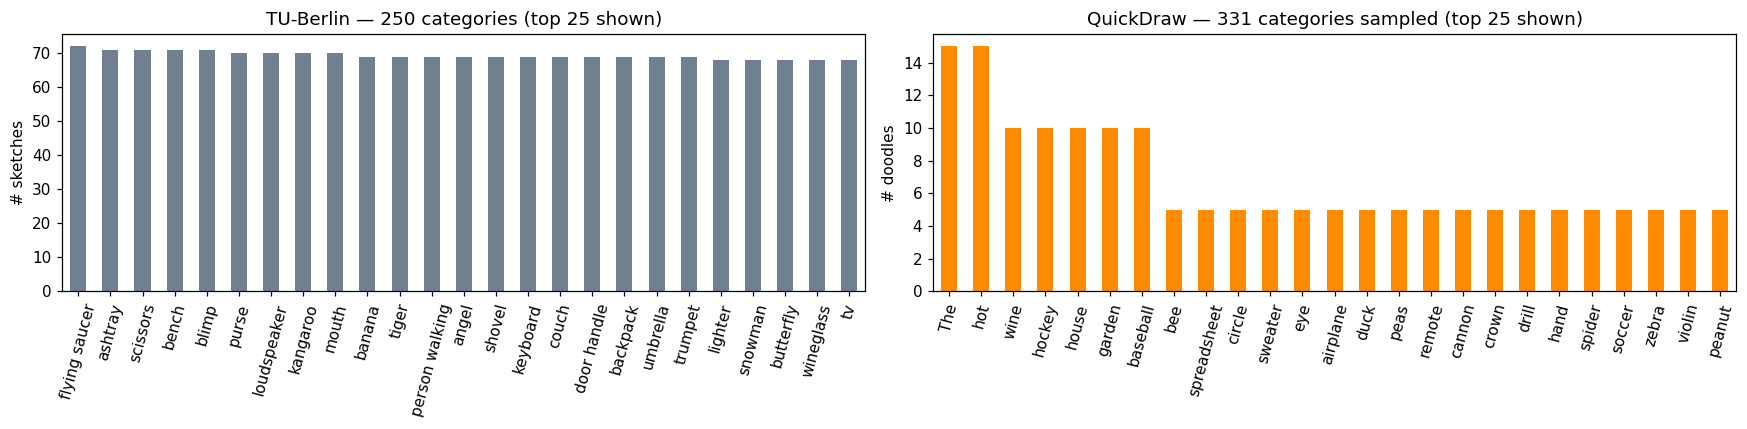

In [10]:
from datasets import load_dataset

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# --- TU-Berlin labels ---
try:
    tu = load_dataset("sdiaeyu6n/tu-berlin", split="train")
    label_col = next(c for c in tu.column_names if "label" in c.lower() or "class" in c.lower())
    labels = tu[label_col]
    # Resolve integer ids → class names if a ClassLabel feature is present
    feat = tu.features[label_col]
    if hasattr(feat, "int2str"):
        labels = [feat.int2str(l) for l in labels]
    counts = pd.Series(collections.Counter(labels)).sort_values(ascending=False)
    counts.head(25).plot(kind="bar", ax=axes[0], color="slategray")
    axes[0].set_title(f"TU-Berlin — {len(counts)} categories (top 25 shown)")
    axes[0].set_ylabel("# sketches"); axes[0].tick_params(axis="x", rotation=75)
except Exception as e:
    axes[0].axis("off"); axes[0].set_title(f"TU-Berlin labels unavailable: {e}")

# --- QuickDraw labels (parsed from filenames) ---
try:
    qd_files = mounted["QuickDraw (doodle)"]["files"]
    cats = [p.stem.split("_")[1] for p in qd_files]   # qd_<category>_NNNN.png
    counts = pd.Series(collections.Counter(cats)).sort_values(ascending=False)
    counts.head(25).plot(kind="bar", ax=axes[1], color="darkorange")
    axes[1].set_title(f"QuickDraw — {len(counts)} categories sampled (top 25 shown)")
    axes[1].set_ylabel("# doodles"); axes[1].tick_params(axis="x", rotation=75)
except Exception as e:
    axes[1].axis("off"); axes[1].set_title(f"QuickDraw labels unavailable: {e}")

plt.tight_layout(); plt.show()

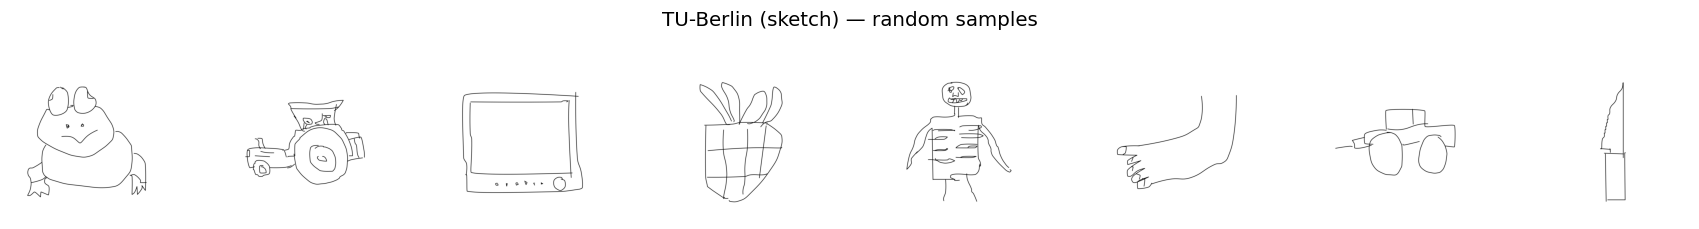

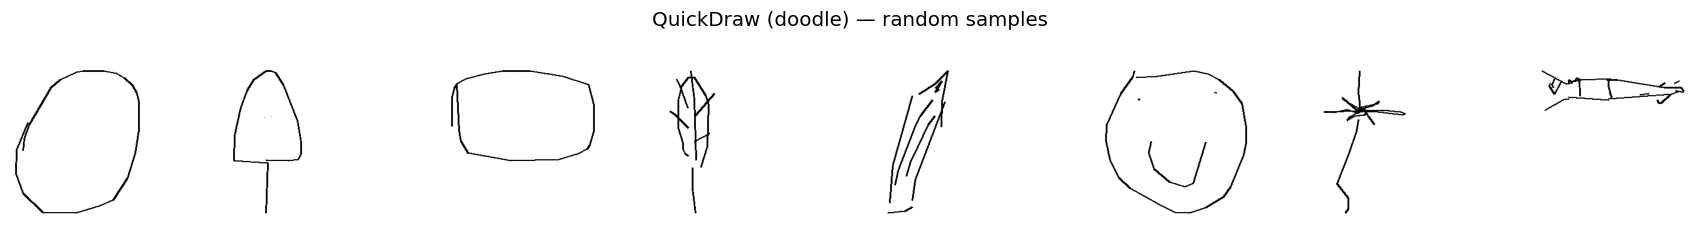

In [11]:
def show_samples(files, n=8, title=""):
    picks = random.sample(files, min(n, len(files)))
    cols = min(n, 8); rows = (len(picks) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2 * rows))
    axes = np.atleast_2d(axes)
    for ax, p in zip(axes.flat, picks):
        try:
            ax.imshow(Image.open(p).convert("RGB"))
        except Exception:
            pass
        ax.axis("off")
    for ax in axes.flat[len(picks):]:
        ax.axis("off")
    fig.suptitle(title, y=1.02, fontsize=13)
    plt.tight_layout(); plt.show()

for name, info in mounted.items():
    show_samples(info["files"], n=8, title=f"{name} — random samples")

In [12]:
rows = []
for name, info in mounted.items():
    files = info["files"]
    df    = image_properties(files, n=200)
    rows.append({
        "domain":     name,
        "path":       str(info["path"]),
        "images":     len(files),
        "mean_w×h":   f"{df['width'].mean():.0f} × {df['height'].mean():.0f}" if not df.empty else "—",
        "modes":      ", ".join(df["mode"].unique()) if not df.empty else "—",
        "total_MB":   round(sum(p.stat().st_size for p in files) / 1024**2, 1),
    })

pd.DataFrame(rows).set_index("domain")

,path,images,mean_w×h,modes,total_MB
domain,,,,,
TU-Berlin (sketch),/kaggle/working/tu_berlin_sketches,2000,1111 × 1111,RGB,110.0
QuickDraw (doodle),/kaggle/working/quickdraw_doodles,1700,256 × 256,RGB,3.2


In [13]:
# # Fallback: build a tiny synthetic dataset so the notebook always runs.
# # This is ONLY used when Kaggle datasets are not attached.
# def make_synthetic(root, n, kind):
#     root = Path(root); root.mkdir(parents=True, exist_ok=True)
#     rng = np.random.default_rng(0 if kind == "sketch" else 1)
#     paths = []
#     for i in range(n):
#         img = np.ones((128, 128, 3), dtype=np.uint8) * 255
#         for _ in range(rng.integers(3, 8)):
#             x0, y0 = rng.integers(0, 120, 2); x1, y1 = rng.integers(0, 120, 2)
#             color = (0, 0, 0) if kind == "sketch" else tuple(int(v) for v in rng.integers(0, 255, 3))
#             # draw a simple line by manipulating array
#             xs = np.linspace(x0, x1, 200).astype(int); ys = np.linspace(y0, y1, 200).astype(int)
#             xs = np.clip(xs, 0, 127); ys = np.clip(ys, 0, 127)
#             img[ys, xs] = color
#         if kind == "photo":
#             # tint with random pastel background
#             bg = rng.integers(180, 255, 3)
#             mask = (img == 255).all(-1)
#             img[mask] = bg
#         p = root / f"{kind}_{i:05d}.png"
#         Image.fromarray(img).save(p)
#         paths.append(p)
#     return paths

# if len(sketch_files) == 0:
#     print("⚠️  No sketch dataset found — generating synthetic fallback.")
#     sketch_files = make_synthetic("/kaggle/working/_synth/sketch", 400, "sketch")
# if len(photo_files) == 0:
#     print("⚠️  No photo dataset found — generating synthetic fallback.")
#     photo_files  = make_synthetic("/kaggle/working/_synth/photo",  400, "photo")

# print(f"Final counts → Sketch: {len(sketch_files)} | Photo: {len(photo_files)}")


In [14]:
class UnpairedImageDataset(Dataset):
    """Returns a sketch and an *independently sampled* photo — unpaired."""
    def __init__(self, files_A, files_B, image_size=128, training=True):
        self.files_A = list(files_A)
        self.files_B = list(files_B)
        aug = []
        if training:
            aug.append(T.RandomHorizontalFlip(p=0.5))
        self.transform = T.Compose([
            T.Resize(int(image_size * 1.12), antialias=True),
            T.CenterCrop(image_size) if not training else T.RandomCrop(image_size),
            *aug,
            T.ToTensor(),                          # → [0,1]
            T.Normalize([0.5]*3, [0.5]*3),          # → [-1,1]
        ])

    def __len__(self):
        return max(len(self.files_A), len(self.files_B))

    def _load(self, path):
        img = Image.open(path).convert("RGB")
        return self.transform(img)

    def __getitem__(self, idx):
        a = self._load(self.files_A[idx % len(self.files_A)])
        b = self._load(random.choice(self.files_B))     # unpaired → independent sample
        return {"A": a, "B": b}

# 90 / 10 split for eval
def split(files, val_frac=0.1):
    k = max(1, int(len(files) * val_frac))
    return files[:-k], files[-k:]

trA, vaA = split(sketch_files)
trB, vaB = split(photo_files)

train_ds = UnpairedImageDataset(trA, trB, CFG.image_size, training=True)
val_ds   = UnpairedImageDataset(vaA, vaB, CFG.image_size, training=False)

train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True,
                          num_workers=CFG.num_workers, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,  batch_size=4, shuffle=False,
                          num_workers=CFG.num_workers, pin_memory=True)

print(f"train batches: {len(train_loader)} | val batches: {len(val_loader)}")


train batches: 450 | val batches: 50


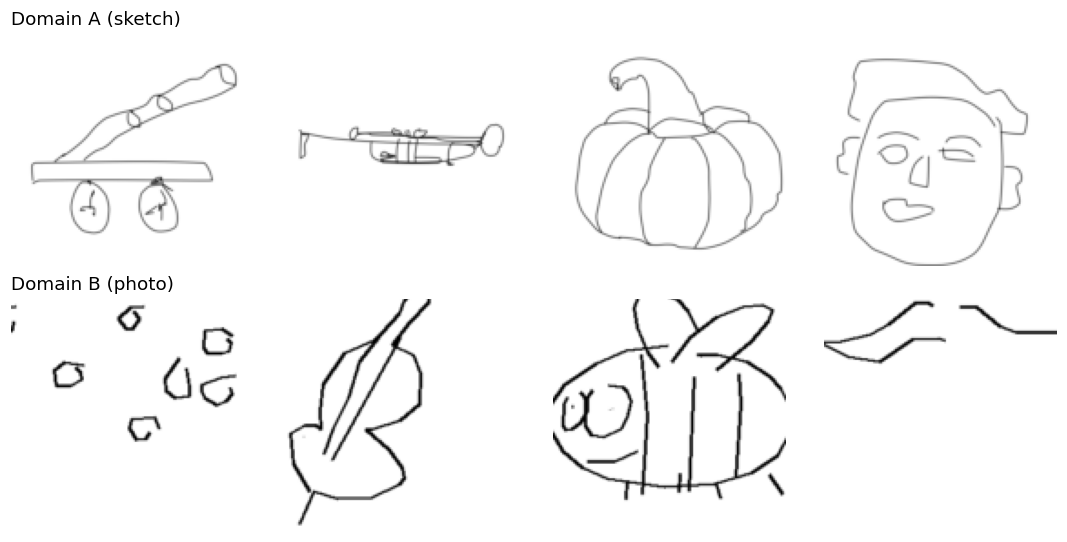

In [15]:
# Sanity-check a batch
def denorm(t):  # [-1,1] → [0,1]
    return (t.clamp(-1, 1) + 1) / 2

sample = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i in range(4):
    axes[0, i].imshow(denorm(sample["A"][i]).permute(1, 2, 0).numpy()); axes[0, i].axis("off")
    axes[1, i].imshow(denorm(sample["B"][i]).permute(1, 2, 0).numpy()); axes[1, i].axis("off")
axes[0, 0].set_title("Domain A (sketch)", loc="left")
axes[1, 0].set_title("Domain B (photo)",  loc="left")
plt.tight_layout(); plt.show()


## 3. Model Architecture

**Generator** — ResNet-based: `c7s1-64 → d128 → d256 → 6×ResBlock(256) → u128 → u64 → c7s1-3`
with instance norm + reflection padding (the original CycleGAN recipe, shrunk to 6 residual blocks as allowed by the brief).

**Discriminator** — 70×70 PatchGAN: it classifies 70×70 patches rather than the whole image, which is sharper for textures and much cheaper to train.


In [16]:
# --------------------- Generator ---------------------

class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(dim, dim, 3), nn.InstanceNorm2d(dim), nn.ReLU(True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(dim, dim, 3), nn.InstanceNorm2d(dim),
        )
    def forward(self, x):
        return x + self.block(x)


class ResNetGenerator(nn.Module):
    def __init__(self, in_ch=3, out_ch=3, ngf=64, n_blocks=6):
        super().__init__()
        layers = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(in_ch, ngf, 7), nn.InstanceNorm2d(ngf), nn.ReLU(True),
        ]
        # down-sampling ×2
        in_f = ngf
        for _ in range(2):
            out_f = in_f * 2
            layers += [
                nn.Conv2d(in_f, out_f, 3, 2, 1),
                nn.InstanceNorm2d(out_f), nn.ReLU(True),
            ]
            in_f = out_f
        # residual blocks
        for _ in range(n_blocks):
            layers.append(ResidualBlock(in_f))
        # up-sampling ×2
        for _ in range(2):
            out_f = in_f // 2
            layers += [
                nn.ConvTranspose2d(in_f, out_f, 3, 2, 1, output_padding=1),
                nn.InstanceNorm2d(out_f), nn.ReLU(True),
            ]
            in_f = out_f
        layers += [
            nn.ReflectionPad2d(3),
            nn.Conv2d(in_f, out_ch, 7),
            nn.Tanh(),                       # → [-1, 1] matches normalized inputs
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


# --------------------- Discriminator (70×70 PatchGAN) ---------------------

class PatchDiscriminator(nn.Module):
    def __init__(self, in_ch=3, ndf=64, n_layers=3):
        super().__init__()
        layers = [nn.Conv2d(in_ch, ndf, 4, 2, 1), nn.LeakyReLU(0.2, True)]
        nf, nf_prev = ndf, ndf
        for i in range(1, n_layers):
            nf_prev, nf = nf, min(nf * 2, 512)
            layers += [
                nn.Conv2d(nf_prev, nf, 4, 2, 1),
                nn.InstanceNorm2d(nf), nn.LeakyReLU(0.2, True),
            ]
        nf_prev, nf = nf, min(nf * 2, 512)
        layers += [
            nn.Conv2d(nf_prev, nf, 4, 1, 1),
            nn.InstanceNorm2d(nf), nn.LeakyReLU(0.2, True),
            nn.Conv2d(nf, 1, 4, 1, 1),        # → N×1×H'×W' patch map
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


def weights_init_normal(m):
    cls = m.__class__.__name__
    if "Conv" in cls:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias.data, 0.0)
    elif "InstanceNorm" in cls and m.weight is not None:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0.0)

# Instantiate the four networks
G_AB = ResNetGenerator(3, 3, n_blocks=CFG.n_res_blocks).to(DEVICE)   # Sketch → Photo
G_BA = ResNetGenerator(3, 3, n_blocks=CFG.n_res_blocks).to(DEVICE)   # Photo  → Sketch
D_A  = PatchDiscriminator(3).to(DEVICE)                               # sketch critic
D_B  = PatchDiscriminator(3).to(DEVICE)                               # photo  critic

for m in (G_AB, G_BA, D_A, D_B):
    m.apply(weights_init_normal)

# Use both T4 GPUs when available
if torch.cuda.device_count() > 1:
    print(f"Wrapping models in DataParallel over {torch.cuda.device_count()} GPUs")
    G_AB = nn.DataParallel(G_AB); G_BA = nn.DataParallel(G_BA)
    D_A  = nn.DataParallel(D_A);  D_B  = nn.DataParallel(D_B)

n_params = sum(p.numel() for p in G_AB.parameters()) / 1e6
print(f"Generator parameters ≈ {n_params:.2f}M each")


Wrapping models in DataParallel over 2 GPUs
Generator parameters ≈ 7.84M each


## 4. Losses, Optimizers, Schedulers

- **Adversarial** — LSGAN (MSE on patch maps) — more stable than BCE.
- **Cycle consistency** — L1 between `x` and `G_BA(G_AB(x))` (and its mirror).
- **Identity** — L1 between `G_AB(b)` and `b` — preserves colour / tone when the input already belongs to the target domain.
- **Optimizer** — Adam with β=(0.5, 0.999), lr=2e-4, linear decay after `decay_start`.


In [17]:
criterion_gan   = nn.MSELoss()
criterion_cycle = nn.L1Loss()
criterion_ident = nn.L1Loss()

opt_G = torch.optim.Adam(
    itertools.chain(G_AB.parameters(), G_BA.parameters()),
    lr=CFG.lr, betas=(CFG.beta1, CFG.beta2),
)
opt_D_A = torch.optim.Adam(D_A.parameters(), lr=CFG.lr, betas=(CFG.beta1, CFG.beta2))
opt_D_B = torch.optim.Adam(D_B.parameters(), lr=CFG.lr, betas=(CFG.beta1, CFG.beta2))

def lr_lambda(epoch):
    # constant for decay_start epochs, then linearly → 0
    if epoch < CFG.decay_start:
        return 1.0
    return max(0.0, 1.0 - (epoch - CFG.decay_start) / (CFG.n_epochs - CFG.decay_start))

sched_G   = torch.optim.lr_scheduler.LambdaLR(opt_G,   lr_lambda)
sched_D_A = torch.optim.lr_scheduler.LambdaLR(opt_D_A, lr_lambda)
sched_D_B = torch.optim.lr_scheduler.LambdaLR(opt_D_B, lr_lambda)

# Mixed-precision scalers (one per optimizer)
scaler_G   = GradScaler(enabled=CFG.use_amp)
scaler_D_A = GradScaler(enabled=CFG.use_amp)
scaler_D_B = GradScaler(enabled=CFG.use_amp)
print("✅ optimizers + schedulers + AMP scalers ready")


✅ optimizers + schedulers + AMP scalers ready


/tmp/ipykernel_314096/2421595241.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_G   = GradScaler(enabled=CFG.use_amp)
/tmp/ipykernel_314096/2421595241.py:24: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_D_A = GradScaler(enabled=CFG.use_amp)
/tmp/ipykernel_314096/2421595241.py:25: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_D_B = GradScaler(enabled=CFG.use_amp)


In [18]:
class ReplayBuffer:
    """Shrivastava et al. — show D a history of generated images to stabilise training."""
    def __init__(self, max_size=50):
        self.max_size = max_size
        self.data = []

    def push_and_pop(self, images):
        out = []
        for img in images.detach():
            img = img.unsqueeze(0)
            if len(self.data) < self.max_size:
                self.data.append(img); out.append(img)
            else:
                if random.random() < 0.5:
                    i = random.randint(0, self.max_size - 1)
                    out.append(self.data[i].clone()); self.data[i] = img
                else:
                    out.append(img)
        return torch.cat(out, 0)

fake_A_buffer = ReplayBuffer()
fake_B_buffer = ReplayBuffer()


## 5. Training Loop

Alternates generator / discriminator updates per batch and tracks every loss for later plotting.


In [19]:
history = {"G": [], "D": [], "cycle": [], "gan": [], "idt": []}

def set_requires_grad(nets, requires_grad=False):
    for net in nets:
        for p in net.parameters():
            p.requires_grad = requires_grad

def save_sample(epoch, loader):
    G_AB.eval(); G_BA.eval()
    batch = next(iter(loader))
    real_A = batch["A"].to(DEVICE); real_B = batch["B"].to(DEVICE)
    with torch.no_grad():
        fake_B = G_AB(real_A); rec_A = G_BA(fake_B)
        fake_A = G_BA(real_B); rec_B = G_AB(fake_A)
    grid = torch.cat([denorm(t[:4].cpu()) for t in
                      (real_A, fake_B, rec_A, real_B, fake_A, rec_B)], 0)
    save_image(make_grid(grid, nrow=4), CFG.sample_dir / f"epoch_{epoch:03d}.png")
    G_AB.train(); G_BA.train()

def save_ckpt(epoch):
    def _s(m): return m.module.state_dict() if isinstance(m, nn.DataParallel) else m.state_dict()
    torch.save({
        "epoch": epoch,
        "G_AB": _s(G_AB), "G_BA": _s(G_BA),
        "D_A":  _s(D_A),  "D_B":  _s(D_B),
        "opt_G":     opt_G.state_dict(),
        "opt_D_A":   opt_D_A.state_dict(),
        "opt_D_B":   opt_D_B.state_dict(),
        "sched_G":   sched_G.state_dict(),
        "sched_D_A": sched_D_A.state_dict(),
        "sched_D_B": sched_D_B.state_dict(),
        "scaler_G":   scaler_G.state_dict(),
        "scaler_D_A": scaler_D_A.state_dict(),
        "scaler_D_B": scaler_D_B.state_dict(),
        "history":    history,
        "best_cycle": best_cycle if "best_cycle" in globals() else float("inf"),
    }, CFG.ckpt_dir / f"cyclegan_epoch_{epoch:03d}.pt")

In [20]:
def train_one_epoch(epoch):
    G_AB.train(); G_BA.train(); D_A.train(); D_B.train()
    running = {k: 0.0 for k in ("G", "D", "cycle", "gan", "idt")}

    for i, batch in enumerate(train_loader):
        real_A = batch["A"].to(DEVICE, non_blocking=True)
        real_B = batch["B"].to(DEVICE, non_blocking=True)

        # -------- 1) Generators --------
        set_requires_grad([D_A, D_B], False)
        opt_G.zero_grad(set_to_none=True)
        with autocast(enabled=CFG.use_amp):
            # Identity
            idt_A = G_BA(real_A); loss_idt_A = criterion_ident(idt_A, real_A)
            idt_B = G_AB(real_B); loss_idt_B = criterion_ident(idt_B, real_B)
            loss_idt = (loss_idt_A + loss_idt_B) * CFG.lambda_identity

            # GAN — fool each discriminator
            fake_B = G_AB(real_A); pred_fake_B = D_B(fake_B)
            loss_gan_AB = criterion_gan(pred_fake_B, torch.ones_like(pred_fake_B))
            fake_A = G_BA(real_B); pred_fake_A = D_A(fake_A)
            loss_gan_BA = criterion_gan(pred_fake_A, torch.ones_like(pred_fake_A))
            loss_gan = loss_gan_AB + loss_gan_BA

            # Cycle
            rec_A = G_BA(fake_B); loss_cyc_A = criterion_cycle(rec_A, real_A)
            rec_B = G_AB(fake_A); loss_cyc_B = criterion_cycle(rec_B, real_B)
            loss_cyc = (loss_cyc_A + loss_cyc_B) * CFG.lambda_cycle

            loss_G = loss_gan + loss_cyc + loss_idt

        scaler_G.scale(loss_G).backward()
        scaler_G.step(opt_G); scaler_G.update()

        # -------- 2) Discriminator A (real sketch vs fake sketch) --------
        set_requires_grad([D_A], True)
        opt_D_A.zero_grad(set_to_none=True)
        with autocast(enabled=CFG.use_amp):
            pred_real = D_A(real_A)
            loss_D_real = criterion_gan(pred_real, torch.ones_like(pred_real))
            fake_A_hist = fake_A_buffer.push_and_pop(fake_A)
            pred_fake = D_A(fake_A_hist.detach())
            loss_D_fake = criterion_gan(pred_fake, torch.zeros_like(pred_fake))
            loss_D_A = 0.5 * (loss_D_real + loss_D_fake)
        scaler_D_A.scale(loss_D_A).backward()
        scaler_D_A.step(opt_D_A); scaler_D_A.update()

        # -------- 3) Discriminator B (real photo vs fake photo) --------
        set_requires_grad([D_B], True)
        opt_D_B.zero_grad(set_to_none=True)
        with autocast(enabled=CFG.use_amp):
            pred_real = D_B(real_B)
            loss_D_real = criterion_gan(pred_real, torch.ones_like(pred_real))
            fake_B_hist = fake_B_buffer.push_and_pop(fake_B)
            pred_fake = D_B(fake_B_hist.detach())
            loss_D_fake = criterion_gan(pred_fake, torch.zeros_like(pred_fake))
            loss_D_B = 0.5 * (loss_D_real + loss_D_fake)
        scaler_D_B.scale(loss_D_B).backward()
        scaler_D_B.step(opt_D_B); scaler_D_B.update()

        loss_D = loss_D_A + loss_D_B

        running["G"]     += loss_G.item()
        running["D"]     += loss_D.item()
        running["cycle"] += loss_cyc.item()
        running["gan"]   += loss_gan.item()
        running["idt"]   += loss_idt.item()

        if (i + 1) % 50 == 0:
            print(f"  [{i+1:4d}/{len(train_loader)}] "
                  f"G={loss_G.item():.3f}  D={loss_D.item():.3f}  cyc={loss_cyc.item():.3f}")

    n = len(train_loader)
    for k in running: running[k] /= n
    return running


In [21]:
import json, shutil


def _l(m):
    return m.module if isinstance(m, nn.DataParallel) else m


def try_resume():
    """Load latest.pt (if it exists) and return (start_epoch, best_cycle, history)."""
    latest = CFG.ckpt_dir / "latest.pt"
    empty_hist = {k: [] for k in ("G", "D", "cycle", "gan", "idt")}

    if not latest.exists():
        print("🆕 no checkpoint found — starting from scratch (epoch 1)")
        return 1, float("inf"), empty_hist

    print(f"♻️  resuming from {latest}")
    ckpt = torch.load(latest, map_location=DEVICE)

    _l(G_AB).load_state_dict(ckpt["G_AB"])
    _l(G_BA).load_state_dict(ckpt["G_BA"])
    _l(D_A ).load_state_dict(ckpt["D_A"])
    _l(D_B ).load_state_dict(ckpt["D_B"])

    # Optional keys — older checkpoints (model-only) still work for resume of just weights
    if "opt_G" in ckpt:
        opt_G.load_state_dict(ckpt["opt_G"])
        opt_D_A.load_state_dict(ckpt["opt_D_A"])
        opt_D_B.load_state_dict(ckpt["opt_D_B"])
    if "sched_G" in ckpt:
        sched_G.load_state_dict(ckpt["sched_G"])
        sched_D_A.load_state_dict(ckpt["sched_D_A"])
        sched_D_B.load_state_dict(ckpt["sched_D_B"])
    if "scaler_G" in ckpt:
        scaler_G.load_state_dict(ckpt["scaler_G"])
        scaler_D_A.load_state_dict(ckpt["scaler_D_A"])
        scaler_D_B.load_state_dict(ckpt["scaler_D_B"])

    start_epoch = ckpt.get("epoch", 0) + 1
    best        = ckpt.get("best_cycle", float("inf"))
    hist        = ckpt.get("history", empty_hist)

    # Fall back to history.json if the checkpoint didn't carry history
    hist_file = CFG.log_dir / "history.json"
    if all(len(v) == 0 for v in hist.values()) and hist_file.exists():
        with open(hist_file) as f:
            hist = json.load(f)

    print(f"   ↳ resumed at epoch {start_epoch}, best cycle so far = {best:.3f}")
    return start_epoch, best, hist


# ---- resume or fresh start ----
start_epoch, best_cycle, history = try_resume()

start = time.time()
for epoch in range(start_epoch, CFG.n_epochs + 1):
    t0 = time.time()
    logs = train_one_epoch(epoch)
    for k in history:
        history[k].append(logs[k])

    sched_G.step(); sched_D_A.step(); sched_D_B.step()

    print(f"[Epoch {epoch:3d}/{CFG.n_epochs}] "
          f"G={logs['G']:.3f}  D={logs['D']:.3f}  cyc={logs['cycle']:.3f}  "
          f"gan={logs['gan']:.3f}  idt={logs['idt']:.3f}  "
          f"({time.time()-t0:.1f}s)")

    # Qualitative sample every epoch
    save_sample(epoch, val_loader)

    # Checkpoint every epoch (overwrites previous "latest" + keeps numbered copy)
    save_ckpt(epoch)
    epoch_ckpt = CFG.ckpt_dir / f"cyclegan_epoch_{epoch:03d}.pt"
    shutil.copy(epoch_ckpt, CFG.ckpt_dir / "latest.pt")

    # Track the best checkpoint by cycle-consistency loss (most meaningful for CycleGAN)
    if logs["cycle"] < best_cycle:
        best_cycle = logs["cycle"]
        shutil.copy(epoch_ckpt, CFG.ckpt_dir / "best.pt")
        print(f"   ↳ new best cycle loss ({best_cycle:.3f}) → best.pt updated")

    # Keep only the last 5 numbered checkpoints to save disk
    # (done AFTER the best.pt copy so we never delete a file we just copied from)
    KEEP_LAST = 5
    numbered = sorted(CFG.ckpt_dir.glob("cyclegan_epoch_*.pt"))
    for old in numbered[:-KEEP_LAST]:
        old.unlink()

    # Persist loss history every epoch so an interruption doesn't lose the curves
    with open(CFG.log_dir / "history.json", "w") as f:
        json.dump(history, f, indent=2)

print(f"\n🏁 total training time: {(time.time()-start)/60:.1f} min")
print(f"📦 checkpoints in {CFG.ckpt_dir}")
print(f"   • {len(list(CFG.ckpt_dir.glob('cyclegan_epoch_*.pt')))} per-epoch files")
print(f"   • latest.pt → most recent")
print(f"   • best.pt   → best cycle loss = {best_cycle:.3f}")

♻️  resuming from /kaggle/working/cyclegan_out/checkpoints/latest.pt
   ↳ resumed at epoch 29, best cycle so far = 0.279


/tmp/ipykernel_314096/2810728670.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG.use_amp):
/tmp/ipykernel_314096/2810728670.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG.use_amp):
/tmp/ipykernel_314096/2810728670.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG.use_amp):


  [  50/450] G=2.137  D=0.162  cyc=0.325
  [ 100/450] G=2.382  D=0.091  cyc=0.252
  [ 150/450] G=1.816  D=0.121  cyc=0.230
  [ 200/450] G=1.696  D=0.089  cyc=0.196
  [ 250/450] G=2.235  D=0.106  cyc=0.342
  [ 300/450] G=2.122  D=0.084  cyc=0.287
  [ 350/450] G=2.043  D=0.071  cyc=0.271
  [ 400/450] G=2.169  D=0.106  cyc=0.364
  [ 450/450] G=1.893  D=0.050  cyc=0.229
[Epoch  29/30] G=2.066  D=0.099  cyc=0.295  gan=1.663  idt=0.108  (190.7s)
  [  50/450] G=1.649  D=0.187  cyc=0.292
  [ 100/450] G=1.840  D=0.110  cyc=0.272
  [ 150/450] G=1.870  D=0.119  cyc=0.275
  [ 200/450] G=2.135  D=0.132  cyc=0.336
  [ 250/450] G=2.223  D=0.098  cyc=0.264
  [ 300/450] G=1.978  D=0.098  cyc=0.224
  [ 350/450] G=1.517  D=0.159  cyc=0.218
  [ 400/450] G=1.875  D=0.118  cyc=0.312
  [ 450/450] G=2.306  D=0.053  cyc=0.392
[Epoch  30/30] G=2.051  D=0.104  cyc=0.312  gan=1.627  idt=0.112  (186.3s)

🏁 total training time: 6.3 min
📦 checkpoints in /kaggle/working/cyclegan_out/checkpoints
   • 5 per-epoch files

## 6. Training Curves

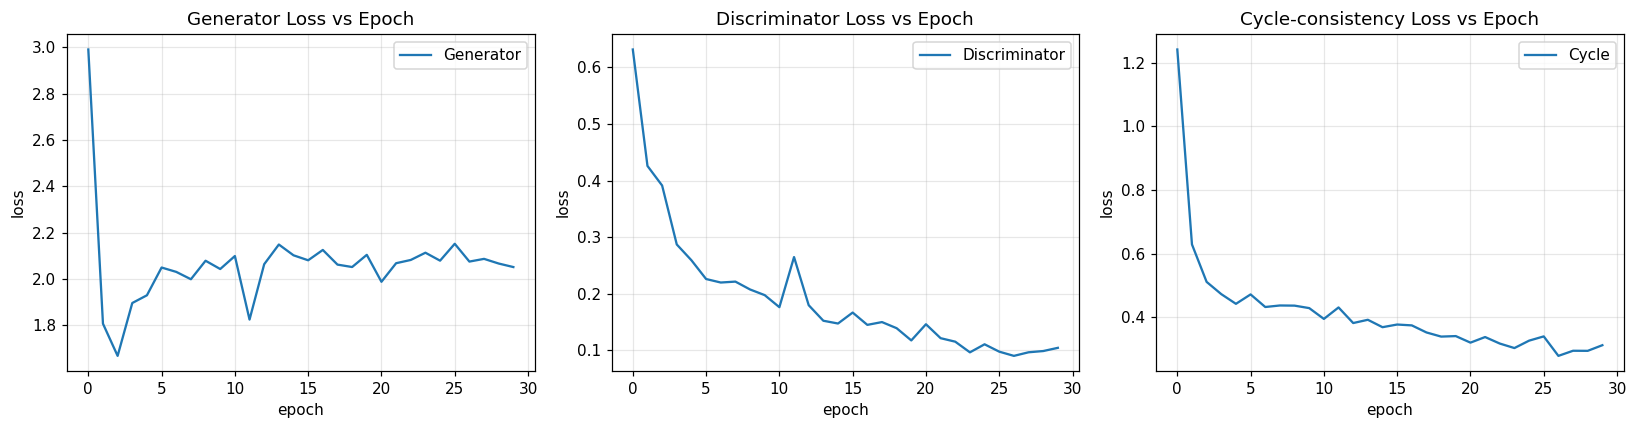

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["G"], label="Generator");     axes[0].set_title("Generator Loss vs Epoch")
axes[1].plot(history["D"], label="Discriminator"); axes[1].set_title("Discriminator Loss vs Epoch")
axes[2].plot(history["cycle"], label="Cycle");     axes[2].set_title("Cycle-consistency Loss vs Epoch")

for ax in axes:
    ax.set_xlabel("epoch"); ax.set_ylabel("loss"); ax.grid(alpha=0.3); ax.legend()

plt.tight_layout()
plt.savefig(CFG.log_dir / "loss_curves.png", dpi=120)
plt.show()


## 7. Qualitative Visualisation

For ≥ 5 examples from each direction, we show:

| column 1 | column 2 | column 3 |
|---|---|---|
| **Input** (real sketch or photo) | **Translated** output (G_AB or G_BA) | **Reconstructed** cycle (back through the other G) |


Sketch → Photo → Sketch


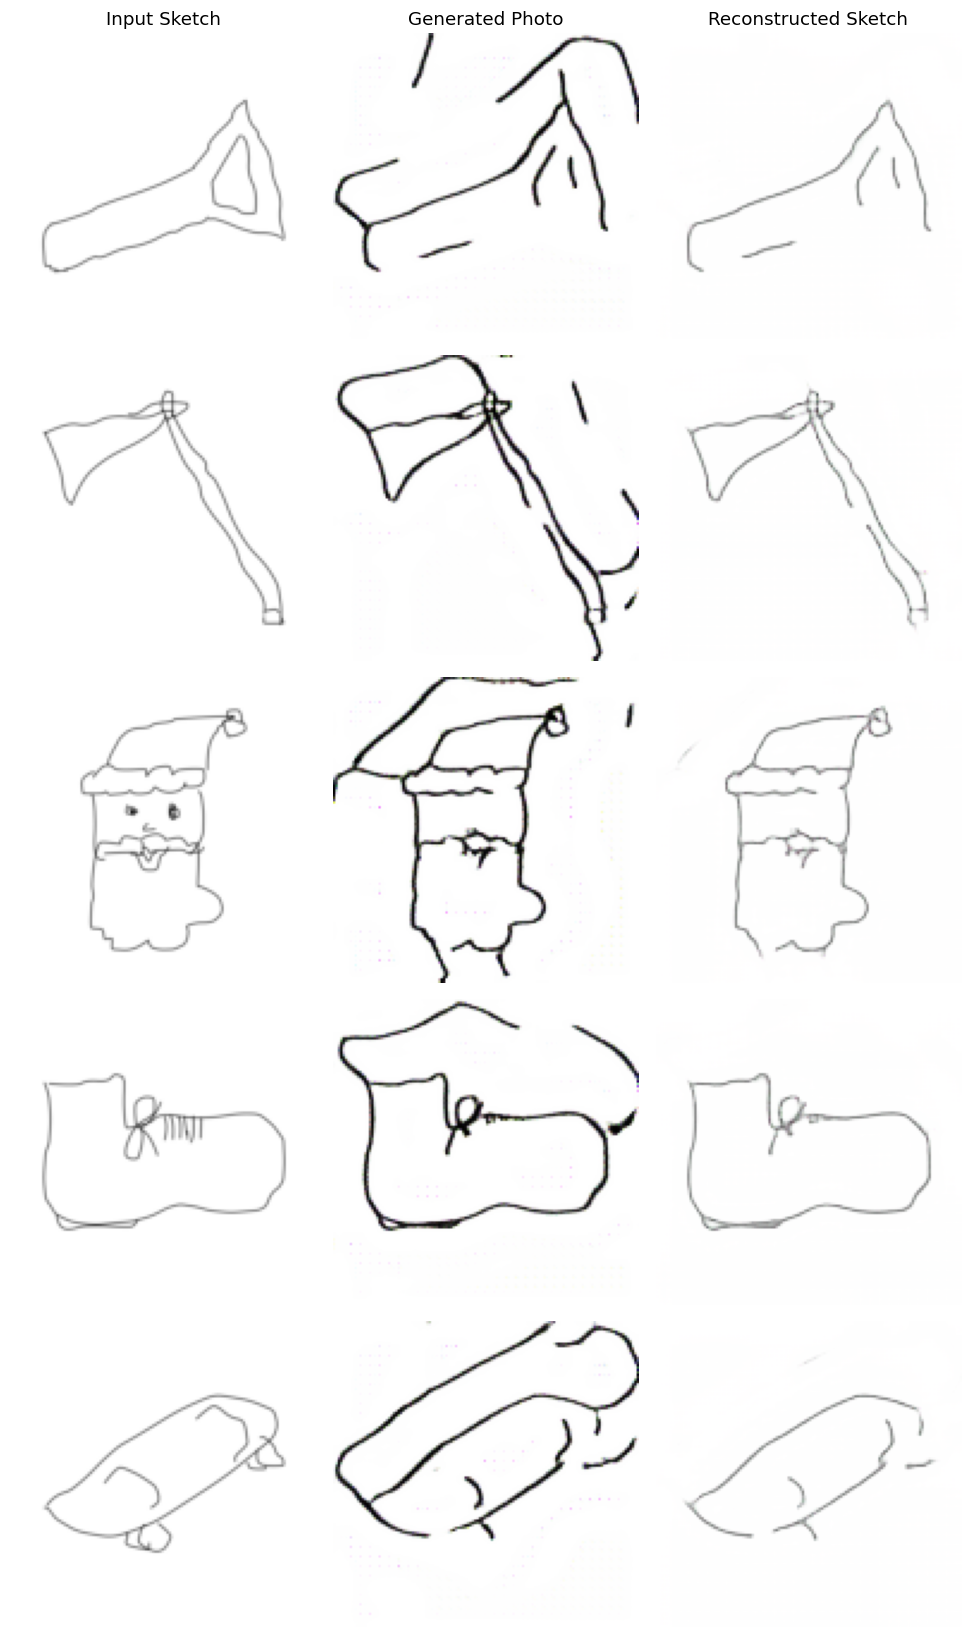

Photo → Sketch → Photo


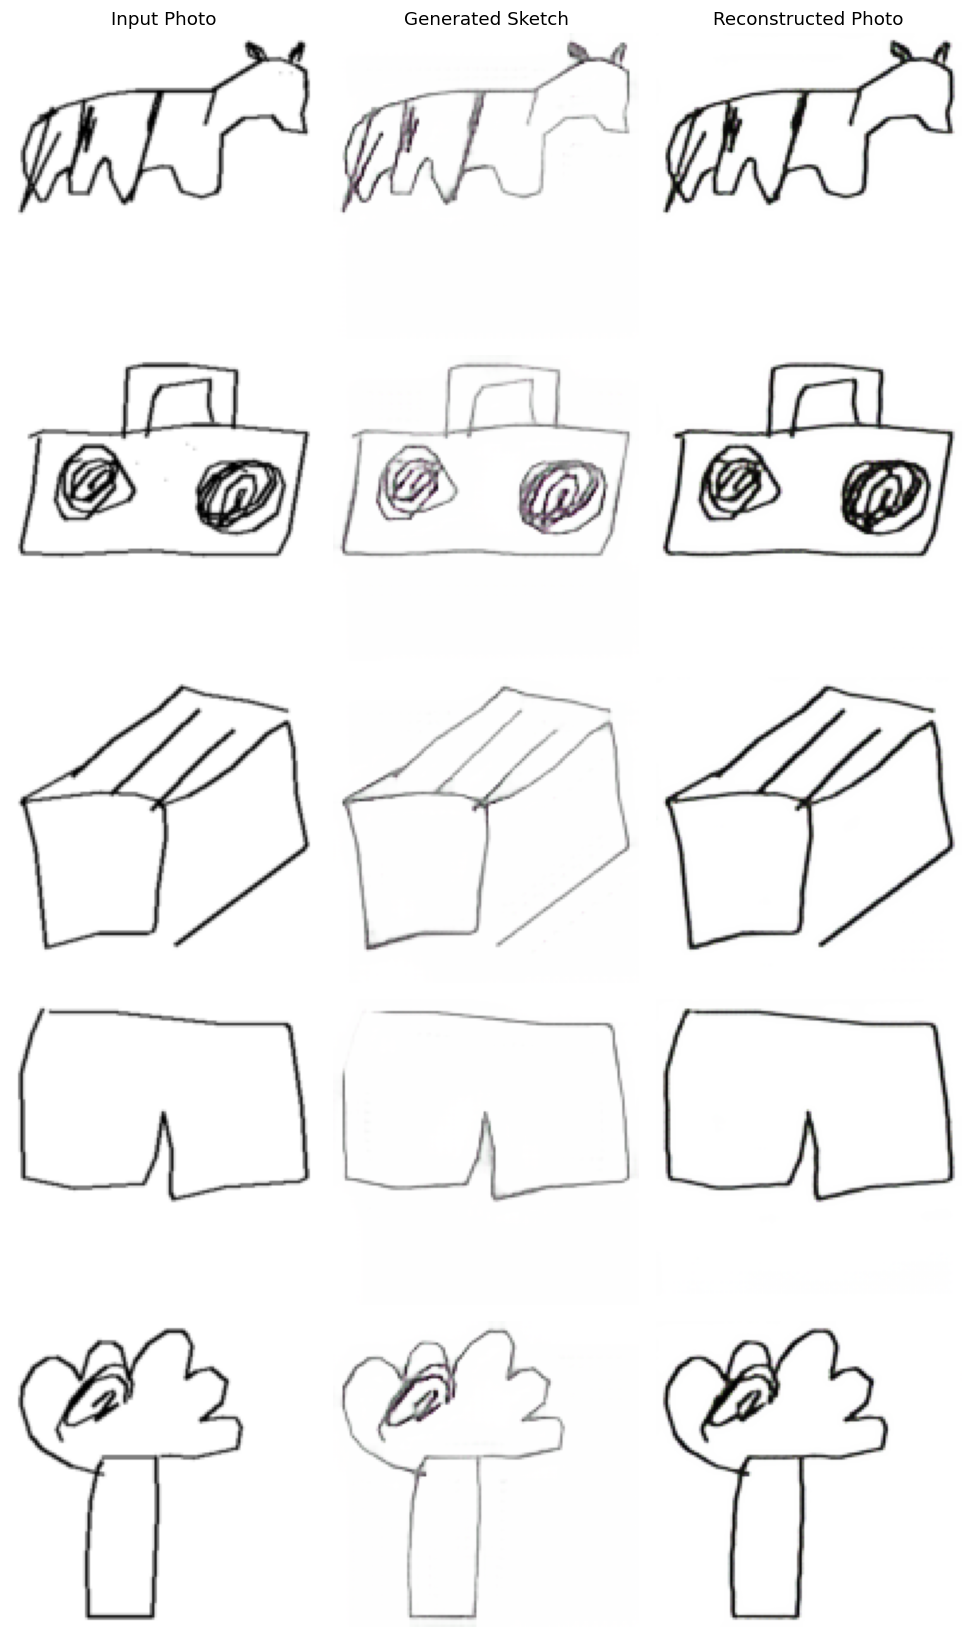

In [23]:
def show_translation(direction="A2B", n=5):
    """direction 'A2B' = sketch → photo → sketch-reconstructed;
       direction 'B2A' = photo  → sketch → photo-reconstructed."""
    G_AB.eval(); G_BA.eval()
    files = sketch_files if direction == "A2B" else photo_files
    picks = random.sample(list(files), n)

    tfm = T.Compose([
        T.Resize(CFG.image_size, antialias=True),
        T.CenterCrop(CFG.image_size),
        T.ToTensor(),
        T.Normalize([0.5]*3, [0.5]*3),
    ])

    fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
    if n == 1: axes = axes[None, :]

    with torch.no_grad():
        for i, p in enumerate(picks):
            img = tfm(Image.open(p).convert("RGB")).unsqueeze(0).to(DEVICE)
            if direction == "A2B":
                translated = G_AB(img); reconstructed = G_BA(translated)
                titles = ("Input Sketch", "Generated Photo", "Reconstructed Sketch")
            else:
                translated = G_BA(img); reconstructed = G_AB(translated)
                titles = ("Input Photo", "Generated Sketch", "Reconstructed Photo")
            panels = [denorm(t.squeeze().cpu()).permute(1, 2, 0).numpy()
                      for t in (img, translated, reconstructed)]
            for j, panel in enumerate(panels):
                axes[i, j].imshow(panel); axes[i, j].axis("off")
                if i == 0: axes[i, j].set_title(titles[j])
    plt.tight_layout(); plt.show()

print("Sketch → Photo → Sketch")
show_translation("A2B", n=5)

print("Photo → Sketch → Photo")
show_translation("B2A", n=5)


## 8. Quantitative Evaluation — SSIM & PSNR

Since CycleGAN learns from **unpaired** data, there is no ground-truth target for a translated image. We therefore report SSIM and PSNR on the **cycle reconstruction** — i.e. `x` vs `G_BA(G_AB(x))` — which directly measures the cycle consistency the model is trained for.


In [27]:
import torch.nn.functional as F

def psnr_torch(a, b, data_range=1.0):
    mse = F.mse_loss(a, b).item()
    return float("inf") if mse == 0 else 20 * math.log10(data_range / math.sqrt(mse))

def ssim_torch(a, b, window=11, data_range=1.0):
    # Simple single-scale SSIM on a batch of [N,C,H,W] tensors in [0,1]
    C1, C2 = (0.01 * data_range) ** 2, (0.03 * data_range) ** 2
    kernel = torch.ones(a.shape[1], 1, window, window, device=a.device) / (window * window)
    pad = window // 2
    mu1 = F.conv2d(a, kernel, padding=pad, groups=a.shape[1])
    mu2 = F.conv2d(b, kernel, padding=pad, groups=b.shape[1])
    mu1_sq, mu2_sq, mu1_mu2 = mu1 * mu1, mu2 * mu2, mu1 * mu2
    sigma1_sq = F.conv2d(a * a, kernel, padding=pad, groups=a.shape[1]) - mu1_sq
    sigma2_sq = F.conv2d(b * b, kernel, padding=pad, groups=b.shape[1]) - mu2_sq
    sigma12   = F.conv2d(a * b, kernel, padding=pad, groups=a.shape[1]) - mu1_mu2
    ssim_map = ((2*mu1_mu2 + C1) * (2*sigma12 + C2)) / \
               ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))
    return ssim_map.mean().item()

def evaluate_cycle(loader, n_batches=None):
    G_AB.eval(); G_BA.eval()
    ssims_A, psnrs_A, ssims_B, psnrs_B = [], [], [], []
    with torch.no_grad():
        for i, batch in enumerate(loader):
            if n_batches and i >= n_batches: break
            real_A = batch["A"].to(DEVICE); real_B = batch["B"].to(DEVICE)
            rec_A = G_BA(G_AB(real_A)); rec_B = G_AB(G_BA(real_B))

            for orig, rec, ssims, psnrs in [(real_A, rec_A, ssims_A, psnrs_A),
                                            (real_B, rec_B, ssims_B, psnrs_B)]:
                o = denorm(orig); r = denorm(rec)   # [0,1]
                ssims.append(ssim_torch(o, r))
                psnrs.append(psnr_torch(o, r))

    return {
        "SSIM_A (sketch↺)": float(np.mean(ssims_A)),
        "PSNR_A (sketch↺)": float(np.mean(psnrs_A)),
        "SSIM_B (photo↺)":  float(np.mean(ssims_B)),
        "PSNR_B (photo↺)":  float(np.mean(psnrs_B)),
    }

metrics = evaluate_cycle(val_loader)
print("Cycle-reconstruction metrics on validation split:")
for k, v in metrics.items():
    unit = " dB" if "PSNR" in k else ""
    print(f"  {k:22s}: {v:.4f}{unit}")

with open(CFG.log_dir / "metrics.json", "w") as f:
    import json; json.dump(metrics, f, indent=2)

Cycle-reconstruction metrics on validation split:
  SSIM_A (sketch↺)      : 0.9396
  PSNR_A (sketch↺)      : 27.5974 dB
  SSIM_B (photo↺)       : 0.9920
  PSNR_B (photo↺)       : 29.4409 dB


## 9. Export Inference-only Weights for the App

In [25]:
# Save small, clean generator-only weights (no DataParallel wrapper) for Gradio
def strip_dp(m): return m.module if isinstance(m, nn.DataParallel) else m

torch.save(strip_dp(G_AB).state_dict(), CFG.out_dir / "G_AB_sketch2photo.pt")
torch.save(strip_dp(G_BA).state_dict(), CFG.out_dir / "G_BA_photo2sketch.pt")
print("Saved:")
for f in CFG.out_dir.glob("G_*.pt"):
    print(" ", f, f"{f.stat().st_size/1e6:.1f} MB")


Saved:
  /kaggle/working/cyclegan_out/G_BA_photo2sketch.pt 31.4 MB
  /kaggle/working/cyclegan_out/G_AB_sketch2photo.pt 31.4 MB


In [29]:
with open("/kaggle/working/requirements.txt", "w") as f:
    f.write("torch\ntorchvision\ngradio\nPillow\n")

## 10. Gradio Deployment App

This section builds a Gradio UI right inside the notebook. Running the cell opens a public share link (Kaggle allows this when "Internet" is enabled). The same UI, unchanged, is also written to `/kaggle/working/app.py` so it can be pushed to Hugging Face Spaces.


In [28]:
APP_CODE = '''\
import torch, torch.nn as nn
from PIL import Image
import torchvision.transforms as T
import gradio as gr

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG = 128

# --- same architecture as training ---
class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1), nn.Conv2d(dim,dim,3), nn.InstanceNorm2d(dim), nn.ReLU(True),
            nn.ReflectionPad2d(1), nn.Conv2d(dim,dim,3), nn.InstanceNorm2d(dim))
    def forward(self,x): return x+self.block(x)

class ResNetGenerator(nn.Module):
    def __init__(self,in_ch=3,out_ch=3,ngf=64,n_blocks=6):
        super().__init__()
        L=[nn.ReflectionPad2d(3),nn.Conv2d(in_ch,ngf,7),nn.InstanceNorm2d(ngf),nn.ReLU(True)]
        f=ngf
        for _ in range(2):
            L+=[nn.Conv2d(f,f*2,3,2,1),nn.InstanceNorm2d(f*2),nn.ReLU(True)]; f*=2
        for _ in range(n_blocks): L.append(ResidualBlock(f))
        for _ in range(2):
            L+=[nn.ConvTranspose2d(f,f//2,3,2,1,output_padding=1),nn.InstanceNorm2d(f//2),nn.ReLU(True)]; f//=2
        L+=[nn.ReflectionPad2d(3),nn.Conv2d(f,out_ch,7),nn.Tanh()]
        self.model=nn.Sequential(*L)
    def forward(self,x): return self.model(x)

def load(weights):
    g=ResNetGenerator().to(DEVICE); g.load_state_dict(torch.load(weights,map_location=DEVICE)); g.eval(); return g

G_AB = load("G_AB_sketch2photo.pt")  # sketch -> photo
G_BA = load("G_BA_photo2sketch.pt")  # photo  -> sketch

pre = T.Compose([T.Resize(IMG, antialias=True), T.CenterCrop(IMG),
                 T.ToTensor(), T.Normalize([0.5]*3,[0.5]*3)])

def translate(img, direction):
    if img is None: return None
    x = pre(img.convert("RGB")).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        y = (G_AB if direction=="Sketch → Photo" else G_BA)(x)
    y = (y.clamp(-1,1)+1)/2
    return T.ToPILImage()(y.squeeze(0).cpu())

with gr.Blocks(title="CycleGAN Sketch ↔ Photo") as demo:
    gr.Markdown("# 🖼️ CycleGAN — Sketch ↔ Photo")
    gr.Markdown("Upload a sketch or a photo, pick a direction, and get the translation.")
    with gr.Row():
        inp = gr.Image(type="pil", label="Input")
        out = gr.Image(type="pil", label="Translated Output")
    direction = gr.Radio(["Sketch → Photo","Photo → Sketch"],
                         value="Sketch → Photo", label="Direction")
    btn = gr.Button("Translate", variant="primary")
    btn.click(translate, [inp, direction], out)

if __name__ == "__main__":
    demo.launch(share=True)
'''

with open("/kaggle/working/app.py", "w") as f:
    f.write(APP_CODE)

print("✅ /kaggle/working/app.py written — upload it alongside the two .pt files to a HF Space.")


✅ /kaggle/working/app.py written — upload it alongside the two .pt files to a HF Space.


In [26]:
# Launch Gradio inline, right here in the notebook
import gradio as gr
import torchvision.transforms as T

def strip_dp(m): return m.module if isinstance(m, nn.DataParallel) else m
_G_AB = strip_dp(G_AB).eval()
_G_BA = strip_dp(G_BA).eval()

_pre = T.Compose([
    T.Resize(CFG.image_size, antialias=True),
    T.CenterCrop(CFG.image_size),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3),
])

def _translate(img, direction):
    if img is None: return None
    x = _pre(img.convert("RGB")).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        y = (_G_AB if direction == "Sketch → Photo" else _G_BA)(x)
    return T.ToPILImage()(denorm(y.squeeze(0).cpu()))

with gr.Blocks(title="CycleGAN Sketch ↔ Photo") as demo:
    gr.Markdown("# 🖼️ CycleGAN — Sketch ↔ Photo")
    with gr.Row():
        inp = gr.Image(type="pil", label="Input")
        out = gr.Image(type="pil", label="Translated")
    direction = gr.Radio(["Sketch → Photo", "Photo → Sketch"],
                         value="Sketch → Photo", label="Direction")
    gr.Button("Translate", variant="primary").click(_translate, [inp, direction], out)

demo.launch(share=True, debug=False)


ImportError: cannot import name 'HfFolder' from 'huggingface_hub' (/usr/local/lib/python3.12/dist-packages/huggingface_hub/__init__.py)